# PERMEABILITY MEASUREMENT WITH LIQUID PERMEAMETER 
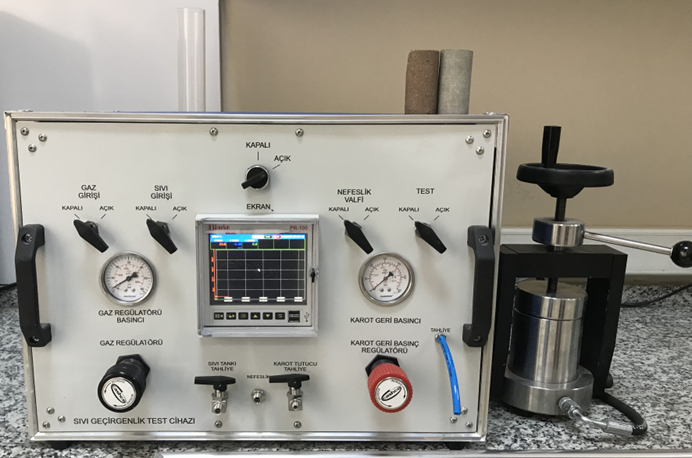

LIQUID PERMEABILITY EXPERIMENT CALCULATIONS

Core Length = 5.800 cm
Core Diameter = 3.700 cm
Core Area = 10.752 cm²
Liquid Viscosity = 1.00 cp

EXPERIMENTAL RESULTS

Experiment #1
P1 = 1.200 bar-g
P1 = 2.184 atm
Q = 0.417 cm³/sec
Q/A = 0.039 cm/sec
ΔP/L = 0.204 atm/cm

Experiment #2
P1 = 1.700 bar-g
P1 = 2.678 atm
Q = 0.781 cm³/sec
Q/A = 0.073 cm/sec
ΔP/L = 0.289 atm/cm

Experiment #3
P1 = 2.700 bar-g
P1 = 3.665 atm
Q = 1.573 cm³/sec
Q/A = 0.146 cm/sec
ΔP/L = 0.459 atm/cm

Experiment #4
P1 = 4.200 bar-g
P1 = 5.145 atm
Q = 2.800 cm³/sec
Q/A = 0.260 cm/sec
ΔP/L = 0.715 atm/cm

k/μ = 0.4357
Liquid Permeability (kₗ) = 435.734 mD
R² = 0.9997


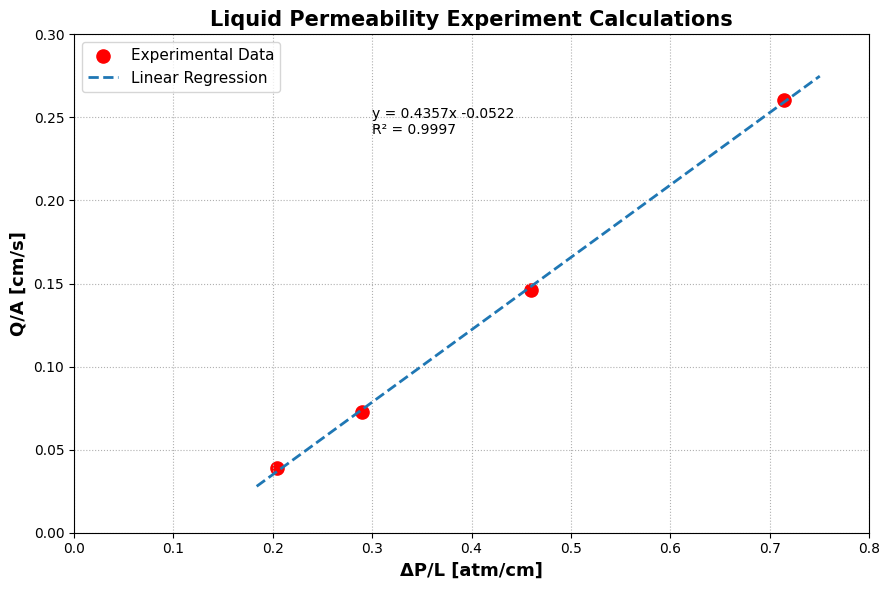

In [2]:
# Liquid Permeability Experiment Calculations
# Code written by Sukru Merey
# 17/05/2026

"""
The permeability of the selected core plug sample was measured 
using a liquid permeameter.

The core plug was fully saturated with water (100% saturation). 
Low flow rates were intentionally selected to ensure that the 
flow conditions remained within the Darcy flow regime.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# -----------------------------
# CORE DATA
# -----------------------------
L = 5.800          # Core length, cm
D = 3.700          # Core diameter, cm
mu = 1.0           # Liquid (water) viscosity, cp

# Cross-sectional area
A = np.pi * (D**2) / 4

print("="*60)
print("LIQUID PERMEABILITY EXPERIMENT CALCULATIONS")
print("="*60)

print(f"\nCore Length = {L:.3f} cm")
print(f"Core Diameter = {D:.3f} cm")
print(f"Core Area = {A:.3f} cm²")
print(f"Liquid Viscosity = {mu:.2f} cp")

# -----------------------------
# EXPERIMENTAL DATA
# -----------------------------
# Inlet pressure (bar-g)
P1_bar = np.array([1.2, 1.7, 2.7, 4.2])

# Outlet pressure (bar-g)
P2_bar = np.array([0.0, 0.0, 0.0, 0.0])

# Produced liquid volume (cm³)
V = np.array([50.0, 50.0, 50.0, 50.0])

# Flow time (sec)
t = np.array([120.0, 64.0, 31.79, 17.86])

# -----------------------------
# UNIT CONVERSIONS
# -----------------------------
# Convert pressure from bar-g to atm
P1_atm = P1_bar * 0.987 + 1.0
P2_atm = P2_bar * 0.987 + 1.0

# Pressure drop
deltaP = P1_atm - P2_atm

# Pressure gradient
deltaP_over_L = deltaP / L

# Flow rate
Q = V / t

# Darcy velocity
Q_over_A = Q / A

# -----------------------------
# LINEAR REGRESSION
# Darcy Equation:
# Q/A = (k/μ) × (ΔP/L)
# -----------------------------
slope, intercept, r_value, p_value, std_err = linregress(
    deltaP_over_L,
    Q_over_A
)

# Permeability calculation
# Since viscosity = 1 cp:
# k = slope × 1000
# (Darcy → milliDarcy)

k_mD = slope * 1000

# -----------------------------
# RESULTS
# -----------------------------
print("\n" + "="*60)
print("EXPERIMENTAL RESULTS")
print("="*60)

for i in range(len(P1_bar)):
    print(f"\nExperiment #{i+1}")
    print(f"P1 = {P1_bar[i]:.3f} bar-g")
    print(f"P1 = {P1_atm[i]:.3f} atm")
    print(f"Q = {Q[i]:.3f} cm³/sec")
    print(f"Q/A = {Q_over_A[i]:.3f} cm/sec")
    print(f"ΔP/L = {deltaP_over_L[i]:.3f} atm/cm")

print("\n" + "="*60)
print(f"\033[1mk/μ = {slope:.4f}\033[0m")
print(f"\033[1mLiquid Permeability (kₗ) = {k_mD:.3f} mD\033[0m")
print(f"\033[1mR² = {r_value**2:.4f}\033[0m")
print("="*60)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(9,6))

# Experimental data points
plt.scatter(
    deltaP_over_L,
    Q_over_A,
    c="r",
    s=90,
    label='Experimental Data'
)

# Regression line
x_line = np.linspace(
    min(deltaP_over_L)*0.9,
    max(deltaP_over_L)*1.05,
    100
)

y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    linestyle='--',
    linewidth=2,
    label='Linear Regression'
)

# Equation text
eq_text = (
    f"y = {slope:.4f}x "
    f"{intercept:+.4f}\n"
    f"R² = {r_value**2:.4f}"
)

plt.text(
    0.30,
    0.24,
    eq_text,
    fontsize=10
)

# Axis labels
plt.xlabel(
    "ΔP/L [atm/cm]",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Q/A [cm/s]",
    fontsize=13,
    fontweight="bold"
)

# Title
plt.title(
    "Liquid Permeability Experiment Calculations",
    fontsize=15,
    fontweight='bold'
)

# Legend
plt.legend(fontsize=11)

# Grid
plt.grid(True, linestyle=':')

# Axis limits
plt.xlim(0.0, 0.8)
plt.ylim(0.0, 0.30)

plt.tight_layout()
plt.show()